# Lineáris modellezés

A lineáris modell egy olyan függvény, amelynek paraméterei: $w_0$, $w_1$, ..., $w_p$,
és az inputként megadott $\underline{x}$=[ $x_1$, ...., $x_p$ \] adatra (_p_ feauture), <br> 
az $w_0 + w_1 x_1 + · · · + w_p x_p$ értéket adja vissza, amit jelöljünk $\hat{y}$-vel. 

Kérdés, hogy ha van sok $\underline{x}_i$ adatunk és előre tudjuk a hozzájuk tartozó elvárt $y_i$ kimeneti értékeket (\[$\underline{x}_i$, $y_i$\] párok), 
akkor melyek az optimális $w_0$, $w_1$, ..., $w_p$ paraméter értékek, 
amelyek minden $\underline{x}_i$-re pontosan a hozzá tartozó $y_i$ eredményt adják ($\hat{y}_i$=$y_i$) vagy legalábbis minél közelebbi értéket (\| $\hat{y}_i$-$y_i$ \|)? 

<br><br>
Formálisan:

\begin{equation}
\hat{y} = w_0 + w_1 x_1 + · · · + w_p x_p = \underline{w} \cdot \underline{x} + w_0
\end{equation}

- $\underline{w}$ = \[ $w_1$, ..., $w_p$ \]: "__coefficients__", paraméterek
- $w_0$ = <i>b</i>: "__intercept__", bias ($y$ tengely metszéspont)

Cél: 

\begin{equation}
min \sum_{\forall [ \underline{x}_i, y_i ]} \| \hat{y}_i - y_i \| = min \sum_{\forall [ \underline{x}_i, y_i ]} \| \underline{w} \cdot \underline{x}_i + w_0 - y_i \|
\end{equation}

vagy (Ordinary Least Squares): 

\begin{equation}
min \sum_{\forall [ \underline{x}_i, y_i ]} ( \hat{y}_i - y_i )^2 
\end{equation}





## Scikit-learn, sklearn (SciPy Toolkit)
- előfeldolgozás, modellezés, kiértékelés, hiperparaméter-optimalizálás
- egyéb (state-of-the-art) matekos eszközkészlet
- együttműködik: numpy-al, pandas-al, matplotlib-bel

## Linear regression *"Hello world!"*

__ML workflow__: 
1. data (preparation)
2. model selection
3. fit
4. predict 
5. metrics
6. (hyperparameter) tuning

In [2]:
# hipersík: bármilyen dimenziaban levo "sík"

# data
import numpy as np
X = np.array([[1], [2], [3]]) # = np.arange(1,4).reshape(3, 1)
y = np.array([1, 2, 3]) # ideális output-ok, y = 1 * x + 0, m = 1, b = 0

# model
#pip install scikit-learn
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# fit
model.fit(X, y)
print("w:", model.coef_) # w vektor
print("b:", model.intercept_) # b bias

# predict
y_pred = model.predict(X)

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("MAE:", mean_absolute_error(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))

w: [1.]
b: 4.440892098500626e-16
MAE: 2.220446049250313e-16
MSE: 8.217301096052207e-32


## Lineáris regresszió, zaj esetén

w:  [3.01428173]  b: [4.93334202]
MAE: 0.8652873006017652 , MSE: 0.8867561410571015


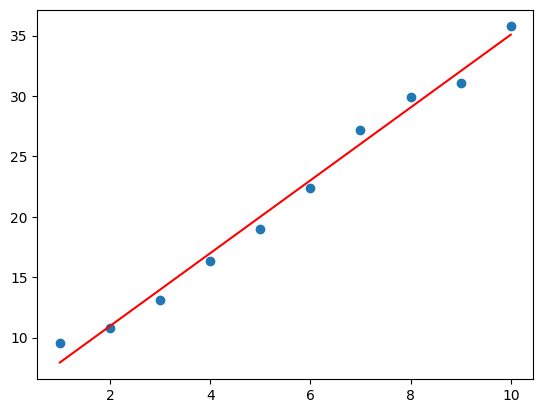

In [ ]:
X = np.arange(1, 11).reshape(10,1) # 2D tömb, egy oszlop - ezert csak egy feature-unk van

m, b = 3, 5 # csak adatgeneráláshoz...
y = m * X + b + np.random.randn(10, 1) # zaj: 0 mean, 1 var.

model = LinearRegression()
model.fit(X, y)
print("w: ", model.coef_[0], " b:", model.intercept_)

y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
print("MAE:", mae, ", MSE:", mse)

import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.plot(X, X * model.coef_[0] + model.intercept_, 'r')
  

## Független változók
2 feature (x1, x2)

          X1        X2
X1  1.000000 -0.013213
X2 -0.013213  1.000000
          X1         Y
X1  1.000000  0.909519
Y   0.909519  1.000000
          X2         Y
X2  1.000000  0.398257
Y   0.398257  1.000000


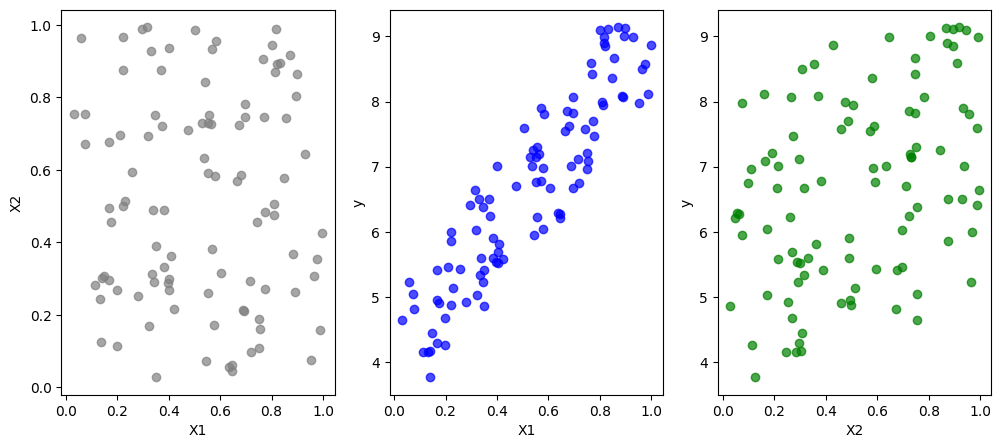

In [ ]:
X1 = np.random.rand(100, 1) # uniform distribution [0, 1) - 100 soros, 1 oszlopos matrixot general 0 es 1 kozotti ertekekkel
X2 = np.random.rand(100, 1) # X1-től független

y = 5 * X1 + 2 * X2 + 3 + np.random.normal(0, 0.1, (100, 1)) # 0.1 variancia

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].scatter(X1, X2, color="gray", alpha=0.7, label="X1 vs X2") # az alpha a pontok átlátszóságát szabályozza, 0.7 azt jelenti hogy 70%-ban átlátszóak lesznek - amikor sok pont van, akkor ez segít vizualizálni a sűrűbb területeket
axes[1].scatter(X1, y, color="blue", alpha=0.7, label="X1 vs y")
axes[2].scatter(X2, y, color="green", alpha=0.7, label="X2 vs y")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("y")
axes[2].set_xlabel("X2")
axes[2].set_ylabel("y")

# Pearson correlation ([-1..1]): |0.5| felett erős a korreláció
# ha 1et kapok akkor teljesen korrelal, ha -1 akkor eppen az ellentettje, ha 0 akkor egyaltalan nem (0.5 felett mar jonak szamit a korr.)
import pandas as pd
df = pd.DataFrame({'X1': X1.flatten(), 'X2': X2.flatten()}) # a flatten() a 2D tömböt 1D-re alakítja, hogy a DataFrame-be helyezhető legyen
print(df.corr()) 
df = pd.DataFrame({'X1': X1.flatten(), 'Y': y.flatten()})
print(df.corr()) 
df = pd.DataFrame({'X2': X2.flatten(), 'Y': y.flatten()})
print(df.corr()) 
# print(np.corrcoef(X1.flatten(), X2.flatten())) # numpy-ban

In [ ]:
from sklearn import linear_model

lr = linear_model.LinearRegression()
lr.fit(np.hstack([X1, X2]), y) # a hstack() a két 2D tömböt egyesíti, így egy 100x2-es mátrixot kapunk, ahol az első oszlop X1 értékeket tartalmazza, a második oszlop pedig X2 értékeket, és az y-t mint célváltozót használjuk
print("w:", lr.coef_, "b:", lr.intercept_)

X = np.hstack([X1, X2])
y_pred = lr.predict(X)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

w: [[4.97438347 2.0296603 ]] b: [3.00514756]


## Függő változók (multikollinearitás)

          X1        X2
X1  1.000000  0.999929
X2  0.999929  1.000000
          X1         Y
X1  1.000000  0.999491
Y   0.999491  1.000000
          X2         Y
X2  1.000000  0.999456
Y   0.999456  1.000000


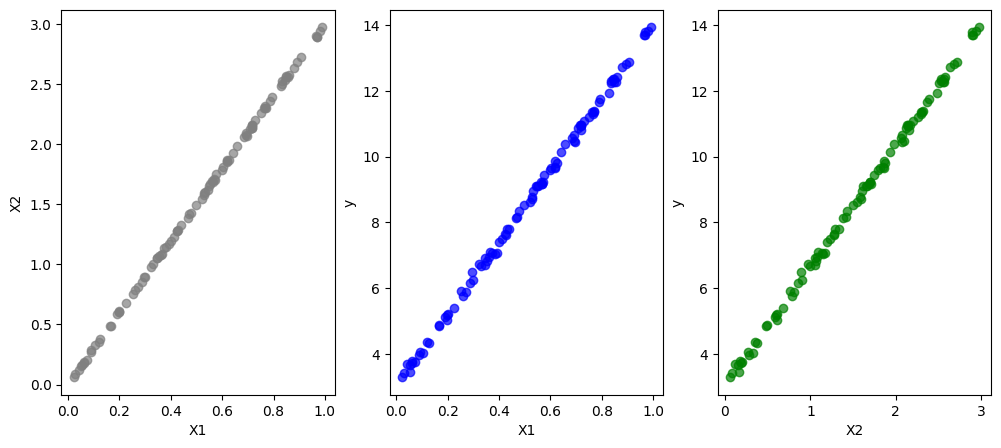

In [ ]:
X1 = np.random.rand(100, 1) # uniform distribution over [0, 1)
X2 = 3 * X1 + np.random.normal(0, 0.01, (100, 1)) # nem fuggetlen!!!!!!!!!!!!!!!!!!!!! mert X1-bol szarmazik, de van egy kis zaj is hozzaadva, hogy ne legyen teljesen korrelalva, hanem csak nagyon erosen (0.01 variancia)

y = 5 * X1 + 2 * X2 + 3 + np.random.normal(0, 0.1, (100, 1)) # 0.1 variancia

_, axes = plt.subplots(1, 3, figsize=(12, 5)) # _ dontcare variable
axes[0].scatter(X1, X2, color="gray", alpha=0.7, label="X1 vs X2")
axes[1].scatter(X1, y, color="blue", alpha=0.7, label="X1 vs y")
axes[2].scatter(X2, y, color="green", alpha=0.7, label="X2 vs y")
axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[1].set_xlabel("X1")
axes[1].set_ylabel("y")
axes[2].set_xlabel("X2")
axes[2].set_ylabel("y")

df = pd.DataFrame({'X1': X1.flatten(), 'X2': X2.flatten()})
print(df.corr()) 
df = pd.DataFrame({'X1': X1.flatten(), 'Y': y.flatten()})
print(df.corr()) 
df = pd.DataFrame({'X2': X2.flatten(), 'Y': y.flatten()})
print(df.corr()) 

## Multikollinearitás probléma
Zaj kilengéseket okoz a paraméterek meghatározásánál

In [ ]:
# multikollinearitás: amikor a feature-ök között erős korreláció van, akkor a lineáris regresszió nehezen tudja meghatározni a pontos súlyokat, mert nehéz megkülönböztetni, hogy melyik feature mennyire járul hozzá a célváltozóhoz, és ez instabil modelleket eredményezhet, ahol a súlyok nagy értékeket vehetnek fel, vagy akár ellentétes előjelűek lehetnek, mint amire számítanánk, és ezáltal rossz általánosító képességet eredményezhet a modell számára új adatokon.

from sklearn import linear_model

X1 = np.random.rand(100, 1) # uniform distribution over [0, 1)
X2 = 3 * X1 + np.random.normal(0, 0.01, (100, 1)) # nem fuggetlen!!!!!!!!!!!!!!!!!!!!!
y = 5 * X1 + 2 * X2 + 3 + np.random.normal(0, 0.1, (100, 1)) # 0.1 variancia
print("w*:[5, 2], b*: 3")
lr = linear_model.LinearRegression()
lr.fit(np.hstack([X1, X2]), y)
print("w:", lr.coef_, "b:", lr.intercept_)

X = np.hstack([X1, X2])
y_pred = lr.predict(X)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

w*:[5, 2], b*: 3
w: [[4.59431675 2.14213516]] b: [2.99919493]


## 3D vizualizáció - Független változók

w:  [5.05319675 2.34717718] b: 2.874513655905833


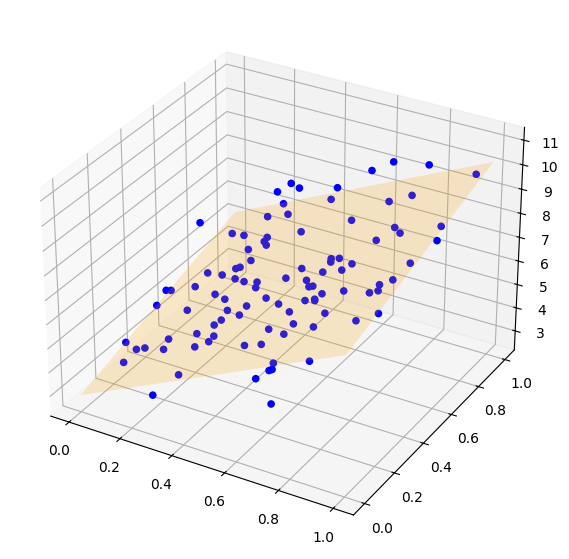

In [7]:
X1 = np.random.rand(100, 1)
X2 = np.random.rand(100, 1)
y = 5 * X1 + 2 * X2 + 3 + 10 * np.random.normal(0, 0.1, (100, 1)) # 5, 2, 3, ZAJ * 10

lr = linear_model.LinearRegression()
lr.fit(np.hstack([X1, X2]), y.flatten())
print("w: ", lr.coef_, "b:", lr.intercept_)

X1_mesh, X2_mesh = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10)) # (10,10), (10,10)
# plt.scatter(X1_mesh.flatten(), X2_mesh.flatten(), color='green', s=1) # s=1 plot size
y_predicted_mesh = lr.coef_[0] * X1_mesh + lr.coef_[1] * X2_mesh + lr.intercept_ # y ertekek minden mesh pontnal

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X1_mesh, X2_mesh, y_predicted_mesh, color='orange', alpha=0.2) # prediction plane, requires 2d arrays
ax.scatter(X1.flatten(), X2.flatten(), y.flatten(), color='blue', alpha=1) # actual data

## 3D vizualizáció - Függő input változók (multikollinearitás)

w:  [6.76996941 1.58201845] b: 2.7451041763539132


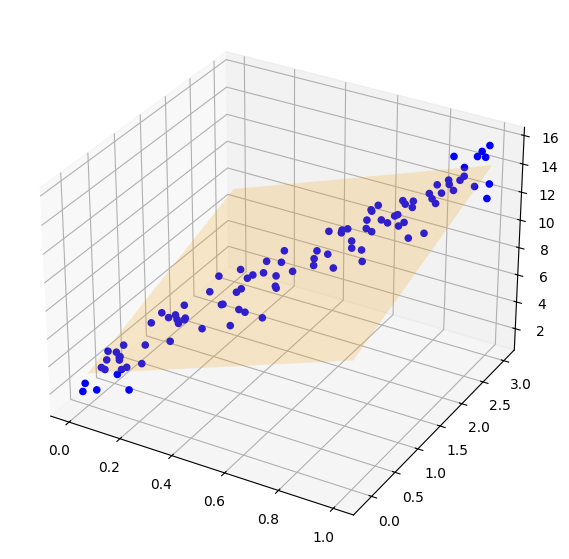

In [10]:
X1 = np.random.rand(100, 1) # -1, 1
X2 = 3 * X1 + np.random.normal(0, 0.1, (100, 1)) # fuggo, -3 3
y = 5 * X1 + 2 * X2 + 3 + 10 * np.random.normal(0, 0.1, (100, 1)) # 5, 2, 3, ZAJ * 10
# print(np.hstack([X1, X2, y])[:3])

lr = linear_model.LinearRegression()
lr.fit(np.hstack([X1, X2]), y.flatten()) # y.flatten() => coef_ lista
print("w: ", lr.coef_, "b:", lr.intercept_)

X1_mesh, X2_mesh = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 3, 10)) # (10,10), (10,10)
y_predicted_mesh = lr.coef_[0] * X1_mesh + lr.coef_[1] * X2_mesh + lr.intercept_ # y ertekek minden mesh pontnal

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X1_mesh, X2_mesh, y_predicted_mesh, color='orange', alpha=0.2) # prediction plane, requires 2d arrays
ax.scatter(X1.flatten(), X2.flatten(), y.flatten(), color='blue', alpha=1) # actual data

# Regularizáció
- Linear regression: 

\begin{equation}
min( \sum (y - \hat{y})^2 )
\end{equation}

- Lasso (L1): 

\begin{equation}
min( \sum (y - \hat{y})^2 + \alpha * \|\underline{w}\|_1 ) = min( \sum (y - \hat{y})^2 + \alpha * \sum |w_i| )
\end{equation}

- Ridge (L2):

\begin{equation}
min( \sum (y - \hat{y})^2 + \alpha *  \|\underline{w}\|_2^2 ) = min( \sum (y - \hat{y})^2 + \alpha *  \sum w_i^2 )
\end{equation}

 
- Elastic-Net (L1 + L2):

\begin{equation}
min( \sum (y - \hat{y})^2 + \alpha * ( l1\_ratio * \sum \|w_i\| + (1-l1\_ratio) * 0.5 * \sum w_i^2  ) )
\end{equation}


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X1 = np.random.rand(1000, 1)
fugges = 0.01 # 0.01: kis függés,  
X2 = X1 * fugges + (1-fugges) * np.random.rand(1000, 1)
X3 = X1 * fugges + (1-fugges) * np.random.rand(1000, 1)
X = np.hstack([X1, X2, X3])
w1, w2, w3, b = 7, 5, 3, 1 # original values
y = b + w1 * X1 + w2 * X2 + w3 * X3 + 0.5 * np.random.randn(1000, 1)

def evaluate_model(model, X, y):
  model.fit(X, y)
  y_pred = model.predict(X)
  mae = mean_absolute_error(y, y_pred)
  mse = mean_squared_error(y, y_pred)
  print(f"{str(model): <20} - MAE: {mae:.4f}, MSE:, {mse:.4f}, ({model.coef_.flatten()}), {model.intercept_}")

linear = LinearRegression() # lr
lasso = Lasso(alpha=1.0) # 0.1: lin-regr legjobb, , 0.0001
ridge = Ridge(alpha=1.0) #
elastic_net = ElasticNet(alpha=1.0, l1_ratio=0.5)

print("Original values:", (w1, w2, w3), ",", b)
evaluate_model(linear, X, y)
evaluate_model(lasso, X, y) # pars. 0-ra leviheti
evaluate_model(ridge, X, y) # params. kicsik, de nem null, az MSE-hez (y-y_pred) a hozaadja a koeff^2-eket (alfaval szorozva)
evaluate_model(elastic_net, X, y) # mennyire vegye figyelembe L1-et vagy L2-t


Original values: (7, 5, 3) , 1
LinearRegression()   - MAE: 0.3980, MSE:, 0.2435, ([7.01523605 4.9628307  3.09897178]), [0.94109855]
Lasso()              - MAE: 2.2049, MSE:, 7.1738, ([0. 0. 0.]), [8.55584869]
Ridge()              - MAE: 0.3984, MSE:, 0.2445, ([6.93178737 4.90544736 3.0590776 ]), [1.0324074]
ElasticNet()         - MAE: 2.1781, MSE:, 7.0093, ([0.14255756 0.         0.        ]), [8.48429452]


## Illusztráció: 
- ténylegesen független változók: $Feature_1, Feature_4, Feature_5$
- nem független változók: $Feature_2, Feature_3$
- Lasso (L1): jellemzők kivonatolására használatos (nullára redukálja a függő koefficienseket, sparsity, feature selection)
- Ridge (L2): a modell általánosító képességét javitja (sok függő feature esetén jobb eredményt érhet el)

True Coefficients: [3.  0.  0.  1.5 0. ]
Linear Coefficients: [ 3.90102803 -0.52449301 -0.68888906  1.41383677 -0.09259407]
Lasso Coefficients: [ 2.57914921  0.          0.          1.27544927 -0.        ]
Ridge Coefficients: [ 3.20013931 -0.13121698 -0.38135978  1.41413253 -0.09546174]


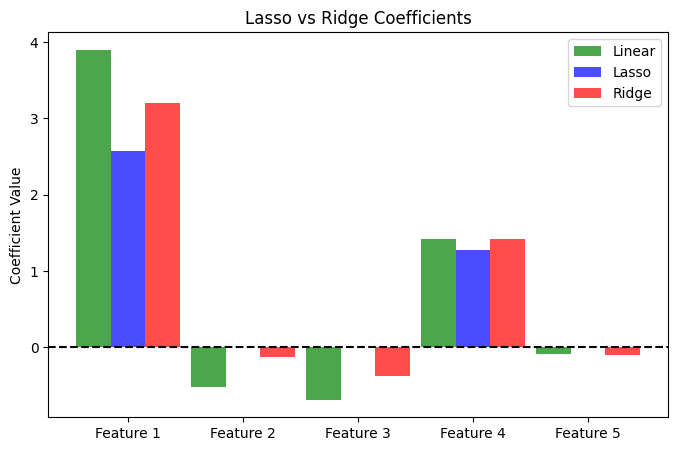

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# Step 1: Create a dataset with collinear features
np.random.seed(42)
n_samples, n_features = 100, 5

# Generate independent variable (base feature)
X_base = np.random.randn(n_samples, 1)

# Create collinear features (high correlation)
X = np.hstack([
    X_base,  # Original feature
    X_base + np.random.normal(0, 0.1, (n_samples, 1)),  # Almost duplicate feature
    X_base + np.random.normal(0, 0.1, (n_samples, 1)),  # Another correlated feature
    np.random.randn(n_samples, 1),  # Independent feature
    np.random.randn(n_samples, 1)   # Another independent feature
])

# True coefficients (only 1st feature matters)
true_coefs = np.array([3, 0, 0, 1.5, 0])  
y = X @ true_coefs + np.random.randn(n_samples) * 0.5  # Add noise; @: dot

# Step 2: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for Lasso and Ridge)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 3: Fit Lasso and Ridge regression models
linear = LinearRegression()  # no penalty
lasso = Lasso(alpha=0.1)  # L1 penalty
ridge = Ridge(alpha=0.1)  # L2 penalty

linear.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

# Step 4: Compare coefficients
print("True Coefficients:", true_coefs)
print("Linear Coefficients:", linear.coef_)
print("Lasso Coefficients:", lasso.coef_)
print("Ridge Coefficients:", ridge.coef_)

# Step 5: Visualize results with side-by-side bars
x = np.arange(n_features)  # Feature indices
width = 0.3  # Width of bars

# Step 6: Visualize results
plt.figure(figsize=(8, 5))
plt.bar(x - width, linear.coef_, width=width, label="Linear", color="green", alpha=0.7)
plt.bar(x, lasso.coef_, width=width, label="Lasso", color="blue", alpha=0.7)
plt.bar(x + width, ridge.coef_, width=width, label="Ridge", color="red", alpha=0.7)

plt.axhline(0, linestyle="--", color="black")
plt.xticks(range(n_features), [f"Feature {i+1}" for i in range(n_features)])
plt.ylabel("Coefficient Value")
plt.title("Lasso vs Ridge Coefficients")
plt.legend()
plt.show()

## Feladat
- adatok betöltése (Car details v3.csv), pandas
- adatok előfeldolgozása:
    - hiányos rekordok (sorok) törlése
    - szöveges oszlopok számmá alakítása
    - kategorikus jellemzők numerikussá alakítása

- lineáris modellezés és regressziós technikák alkalmazása
- célváltozó (függő): selling_price
- független változók: \['year', 'km_driven', 'engine',
       'max_power', 'fuel', 'seller_type', 'transmission'\]
- metrikák kiszámítása 

In [ ]:
import pandas as pd

data = pd.read_csv("Car details v3.csv")

data.dropna(inplace=True) # hiányos rekordok (sorok) törlése

X = data[['year', 'km_driven', 'engine', 'max_power', 'fuel', 'seller_type', 'transmission']].copy() # copy: avoid warning
y = data['selling_price']



In [ ]:
#oran:
# eredmeny: nincs linearis osszefugges a paramterek es az arak kozott

import pandas as pd

data = pd.read_csv("Car details v3.csv")

data.dropna(inplace=True) # hiányos rekordok (sorok) törlése

X = data[['year', 'km_driven', 'engine', 'transmission']].copy() # copy: avoid warning
y = data['selling_price']

X['engine'] = X['engine'].str.replace("CC", "").str.strip()
X['transmission'] = X['transmission'].apply(lambda x: 1 if x == "Automatic" else 0)

